# Policy Iteration implementation on Frozen Lake environment

This project implements **Policy Iteration** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:
grid = generate_grid_randomly(5, 5, n_holes=12)
grid

[['H', 'H', 'H', 'H', 'F'],
 ['H', 'F', 'F', 'F', 'F'],
 ['S', 'F', 'F', 'H', 'F'],
 ['F', 'H', 'H', 'H', 'H'],
 ['H', 'F', 'F', 'G', 'H']]

Now let's create FrozenLakeEnvironment but before that we need to define some constants

## Testing the environment

In [3]:
# let's define grid (we can we the dynamic grid generator too)
lake_grid = [["F", "S", "F", "F"],
             ["F", "H", "F", "H"],
             ["F", "H", "F", "H"],
             ["H", "F", "F", "G"]]

reward_points = {
    "S": -1,
    "G": 10,
    "F": -1,
    "H": -10
}

In [4]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [5]:
n_actions = frozen_lake.n_actions
n_states = frozen_lake.n_states
print("Number of actions: ", n_actions)
print("Number of states: ", n_states)

Number of actions:  4
Number of states:  16


In [6]:
# let's test the move method, if we are at (0, 0) state and try to move up, we should be at the same state
current_state = (0, 0)
action_index = frozen_lake.action_to_idx["up"]
frozen_lake.move(current_state, action_index)

(0, 0)

In [7]:
# let's test the move method, if we are at (0, 0) state and try to move right, we should reach to the (0, 1) state
current_state = (0, 0)
action_index = frozen_lake.action_to_idx["right"]
frozen_lake.move(current_state, action_index)

(0, 1)

In [8]:
# Now let's test the transition prob, if we are at the Goal "G" i.e (3,3) and try to move, we are supposed to stuck to that state
frozen_lake.get_transition_prob((3, 3), action_index)

[{'prob': 1.0, 'new_state': (3, 3), 'reward': 0, 'done': True}]

In [9]:
# Now let's test the transition prob for near goal state
frozen_lake.get_transition_prob((3, 2), action_index)

[{'prob': 0.7, 'new_state': (3, 3), 'reward': 10, 'done': True},
 {'prob': 0.1, 'new_state': (2, 2), 'reward': -1, 'done': False},
 {'prob': 0.1, 'new_state': (3, 1), 'reward': -1, 'done': False},
 {'prob': 0.1, 'new_state': (3, 2), 'reward': -1, 'done': False}]

# Policy Iteration Algorithm Implementation

## Policy Iteration algorithm
Policy Iteration is a Dynamic Programming method that alternates between **policy evaluation** and **policy improvement** to iteratively converge to an optimal policy.

The agent learns to navigate the frozen grid from the start state to the goal while avoiding holes, maximizing expected cumulative reward. 

- The implementation assumes full knowledge of the environment’s transition dynamics and reward function which makes it a ***📌model-based method📌***, and is suitable for small, finite Markov Decision Processes (MDPs).

Key aspects of this implementation include:
- Iterative policy evaluation using Bellman expectation equations
- Greedy policy improvement based on state-action value estimates
- Convergence based on value function stability
- Visualization of the final optimal policy and value function

- Note that the policy, action-value function, and state-value function are generally represented as 1D lists. In this implementation, we simply represent them as 2D arrays to avoid repeatedly converting between row and column indices and a 1D representation.
- A 1D list is practically convenient when actions are deterministic and the transition matrix is represented as a 2D array, where rows represent states and columns represent actions.

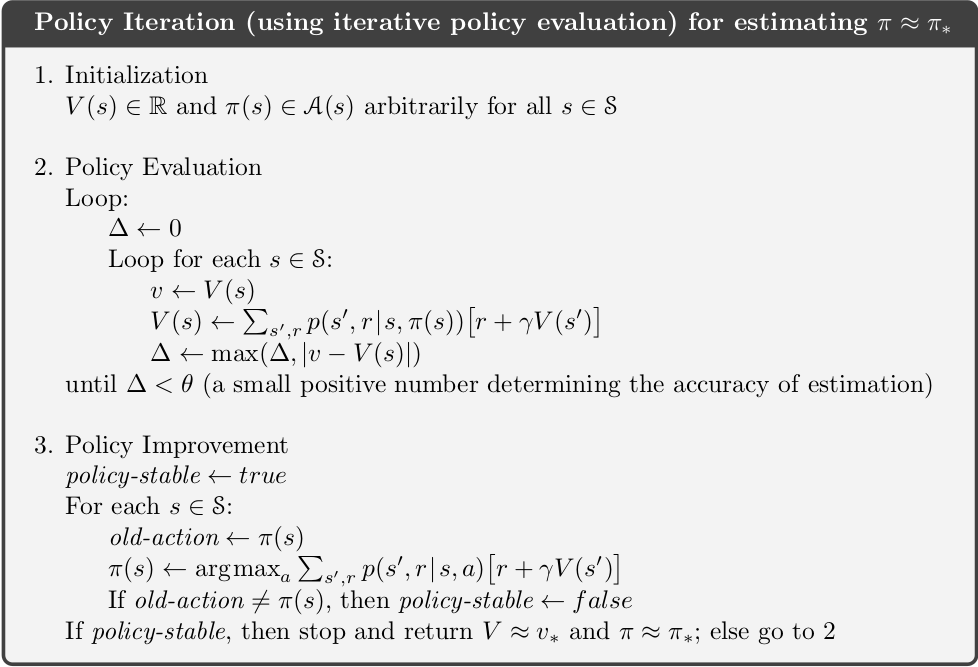

Note: policy iteration is an iteration algorithm with another iterative algorithm embedded in a policy evaluation step to solve Bellman's equation. 

In [10]:
def policy_evaluation(environment, policy, V, gamma=0.99, theta=1e-8):
    while True:
        delta = 0
        for r in range(len(V)):
            for c in range(len(V[0])):
                if environment.grid[r][c] in ["H", "G"]:
                    # terminal states
                    continue
                    
                # state => (r, c)
                action = policy[r][c]
                new_v = 0
                for transition in environment.get_transition_prob((r,c), action):
                    nr, nc = transition["new_state"]
                    new_v += transition["prob"] * (transition["reward"] + gamma * V[nr][nc])
                    
                delta = max(delta, abs(V[r][c] - new_v))
                V[r][c] = new_v
        if delta < theta:
            break
    return V

let's do the sanity test of policy_evaluation() implementatation to make sure there is no syntax error

In [11]:
n_rows, n_cols = frozen_lake.n_rows, frozen_lake.n_cols
policy = np.zeros((n_rows, n_cols))
V = np.zeros((n_rows, n_cols))
policy

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [12]:
policy_evaluation(frozen_lake, policy, V)

array([[-25.72994748, -24.50790871, -23.74517319, -22.88703868],
       [-19.44996084,   0.        , -11.56165132,   0.        ],
       [-15.39265838,   0.        , -10.21090072,   0.        ],
       [  0.        , -10.06248306,  -8.75047717,   0.        ]])

In [13]:
def policy_improvement(environment, V, gamma=0.99):
    new_policy = np.zeros((environment.n_rows, environment.n_cols), dtype=np.int8)
    for r in range(len(V)):
        for c in range(len(V[0])):
            if environment.grid[r][c] in ["H", "G"]:
                    continue #
            # state = (r, c)
            action_values = []
            
            for action in environment.all_action_idx:
                q = 0
                for transition in environment.get_transition_prob((r, c), action):
                    nr, nc = transition["new_state"]
                    q += transition["prob"] * (transition["reward"] + gamma * V[nr][nc])
                action_values.append(q)
            # pick a greedy action with a highest 
            new_policy[r][c] = np.argmax(action_values).item()
    return new_policy    

In [14]:
def policy_iteration(environment):
    policy_history = []
    V_history = []
    n_rows = environment.n_rows
    n_cols = environment.n_cols
    policy = np.zeros((n_rows, n_cols), dtype=np.int8)
    V = np.zeros((n_rows, n_cols), dtype=np.float32)
    while True:
        V = policy_evaluation(environment, policy, V)
        new_policy = policy_improvement(environment, V)
        if np.array_equal(policy, new_policy):
            break
            
        policy = new_policy
        policy_history.append(policy)
        V_history.append(V)
        
    return policy, V, policy_history, V_history

In [15]:
# run the policy iteration function to find the best greedy policy
policy, V, policy_history, V_history = policy_iteration(frozen_lake)

In [16]:
len(policy_history)

5

In [17]:
policy

array([[2, 2, 1, 0],
       [3, 0, 1, 0],
       [3, 0, 1, 0],
       [0, 2, 2, 0]], dtype=int8)

In [18]:
text_policy = []
for r in range(policy.shape[0]):
    col = []
    for c in range(policy.shape[1]):
        col.append(frozen_lake.action_idx_to_name[policy[r][c].item()])
    text_policy.append(col)

In [19]:
text_policy

[['right', 'right', 'down', 'left'],
 ['up', 'left', 'down', 'left'],
 ['up', 'left', 'down', 'left'],
 ['left', 'right', 'right', 'left']]

# Render policy
Let's create a rendering function to visualize the policy clearly.

In [20]:
render_policy_and_value(frozen_lake, policy, V)

Policy:


,0,1,2,3
0,→,🚀 →,↓,←
1,↑,🕳️,↓,🕳️
2,↑,🕳️,↓,🕳️
3,🕳️,→,→,🏁


State-Value Function:


,0,1,2,3
0,-6.94,-5.37,-3.25,-5.18
1,-8.50,0.00,-1.27,0.00
2,-9.65,0.00,2.67,0.00
3,0.00,3.10,8.07,0.00


# Animate policy and state value history

In [21]:
from IPython.display import HTML

In [22]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())

# Let Play with different grid setup

In [23]:
grid = generate_grid_randomly(15, 15, n_holes=50)
grid

[['H', 'F', 'F', 'F', 'F', 'F', 'F', 'H', 'H', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['F', 'F', 'H', 'F', 'F', 'G', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'H', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'H', 'F', 'H', 'F', 'F', 'F', 'F', 'H', 'F', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F', 'H', 'H', 'H', 'H', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'H', 'F', 'S', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'F', 'H', 'H', 'H', 'F'],
 ['F', 'H', 'H', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['F', 'H', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'H', 'F', 'F', 'F'],
 ['F', 'H', 'H', 'F', 'F', 'F', 'H', 'F', 'F', 'F', 'H', 'F', 'F', 'H', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'H', 'H', 'F', 'H', 'F

In [24]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)
policy, V, policy_history, V_history = policy_iteration(frozen_lake)

In [25]:
len(policy_history)

7

In [26]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())